# 01 - Data Ingestion & Structural Audit

Step 1 of the Euro Crop pipeline: load the raw dataset, define a physical plausibility contract per column, and run a three-layer corruption census (null / inf / out-of-range).

## 1.1 — Load raw data and inspect shape / dtypes

In [1]:
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_raw_data

LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_DIR / "01_eda_inspection.log", mode="a"),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)

logger = logging.getLogger("01_eda_inspection")
logger.info("Notebook session started.")

2026-08-20 00:08:46,480 | INFO | 01_eda_inspection | Notebook session started.


In [2]:
df = load_raw_data()

print("Shape:", df.shape)
print()
print("Columns:", list(df.columns))

2026-08-20 00:08:46,483 | INFO | src.data_loader | Loading raw data from /Users/gowrikamahesh/github/euro-crop-logistics-pipeline/data/raw/EuroCrop_agricultural_logistics_dataset.csv


2026-08-20 00:08:46,541 | INFO | src.data_loader | Loaded raw data: 53305 rows, 29 columns


Shape: (53305, 29)

Columns: ['Unnamed: 0', 'Vehicle_Type', 'Crop_Type', 'Harvest_Date', 'Crop_Yield', 'Storage_Temperature', 'Storage_Humidity', 'Fuel_Consumption', 'Route_Distance', 'Delivery_Time', 'Traffic_Level', 'Temperature', 'Humidity', 'Vehicle_Load_Capacity', 'Vibration_Level', 'Queue_Time', 'Weather_Impact', 'Station_Capacity', 'Operational_Cost', 'Energy_Consumption', 'IoT_Sensor_Reading_Temperature', 'IoT_Sensor_Reading_Humidity', 'IoT_Sensor_Reading_Light', 'Warehouse_Storage_Time', 'Inventory_Levels', 'Fuel_Costs', 'Spoilage_Risk', 'Efficiency_Ratio', 'Quality_Maintenance_Ratio']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53305 entries, 0 to 53304
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      53305 non-null  str    
 1   Vehicle_Type                    53305 non-null  str    
 2   Crop_Type                       53305 non-null  str    
 3   Harvest_Date                    53305 non-null  str    
 4   Crop_Yield                      53305 non-null  float64
 5   Storage_Temperature             53305 non-null  float64
 6   Storage_Humidity                53305 non-null  float64
 7   Fuel_Consumption                53305 non-null  float64
 8   Route_Distance                  53305 non-null  float64
 9   Delivery_Time                   53305 non-null  float64
 10  Traffic_Level                   53305 non-null  float64
 11  Temperature                     53305 non-null  float64
 12  Humidity                        53305 non-n

### Reconcile the two temporal columns

The raw CSV has an unnamed leading column (likely a logistics-event timestamp) and a separate `Harvest_Date` column. Parse both as datetimes and check whether they represent different things (event time vs. harvest time) or are redundant.

In [4]:
unnamed_col = df.columns[0]
print(f"Unnamed leading column name: {unnamed_col!r}")

df[unnamed_col] = pd.to_datetime(df[unnamed_col], errors="coerce")
df["Harvest_Date"] = pd.to_datetime(df["Harvest_Date"], errors="coerce")

print("Event timestamp range:", df[unnamed_col].min(), "to", df[unnamed_col].max())
print("Harvest_Date range:", df["Harvest_Date"].min(), "to", df["Harvest_Date"].max())

n_unparseable_event = df[unnamed_col].isna().sum()
n_unparseable_harvest = df["Harvest_Date"].isna().sum()
print(f"\nUnparseable event timestamps: {n_unparseable_event}")
print(f"Unparseable Harvest_Date values: {n_unparseable_harvest}")

n_identical = (df[unnamed_col] == df["Harvest_Date"]).sum()
print(f"\nRows where the two timestamps are identical: {n_identical} / {len(df)}")

Unnamed leading column name: 'Unnamed: 0'
Event timestamp range: 2018-06-01 00:00:00 to 2024-05-29 23:00:00
Harvest_Date range: 2017-01-01 00:00:00 to 2017-12-31 00:00:00

Unparseable event timestamps: 0
Unparseable Harvest_Date values: 0

Rows where the two timestamps are identical: 0 / 53305


## 1.2 — Define the physical plausibility contract

For each numeric column, declare `(min_valid, max_valid, must_be_finite)` based on domain knowledge of European agricultural logistics. Any value outside this contract — or non-finite when finiteness is required — is treated as effectively missing/corrupted, not just an outlier.

`Traffic_Level` and `Weather_Impact` are checked for cardinality first (`.unique()`), since they may be coded indices rather than freely continuous — that decides whether they belong in this numeric contract at all.

In [5]:
for col in ["Traffic_Level", "Weather_Impact"]:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")
    print(sorted(df[col].dropna().unique())[:10], "...\n" if n_unique > 10 else "\n")

Traffic_Level: 401 unique values
[np.float64(1.0), np.float64(1.01), np.float64(1.02), np.float64(1.03), np.float64(1.04), np.float64(1.05), np.float64(1.06), np.float64(1.07), np.float64(1.08), np.float64(1.09)] ...

Weather_Impact: 401 unique values
[np.float64(1.0), np.float64(1.01), np.float64(1.02), np.float64(1.03), np.float64(1.04), np.float64(1.05), np.float64(1.06), np.float64(1.07), np.float64(1.08), np.float64(1.09)] ...



In [6]:
# (min_valid, max_valid, must_be_finite)
# Ranges are deliberately generous but physically bounded for EU truck/rail/air
# agricultural logistics. Revisit after seeing the corruption census below.
CONTRACT = {
    # Environmental sensors
    "Storage_Temperature": (-30, 50, True),
    "Storage_Humidity": (0, 100, True),
    "Temperature": (-30, 50, True),
    "Humidity": (0, 100, True),
    "IoT_Sensor_Reading_Temperature": (-30, 50, True),
    "IoT_Sensor_Reading_Humidity": (0, 100, True),
    "IoT_Sensor_Reading_Light": (0, 200_000, True),  # lux, generous daylight bound
    "Vibration_Level": (0, 100, True),  # sensor-unit bound, refine after EDA

    # Logistics / operational
    "Crop_Yield": (0, 100_000, True),  # tonnes, generous upper bound
    "Fuel_Consumption": (0, 10_000, True),
    "Route_Distance": (0, 5_000, True),  # km, plausible max intra-EU haul
    "Delivery_Time": (0, 5_000, True),  # hours
    "Vehicle_Load_Capacity": (0, 100_000, True),  # kg
    "Queue_Time": (0, 1_000, True),  # hours
    "Station_Capacity": (0, 1_000_000, True),
    "Operational_Cost": (0, 1_000_000, True),
    "Energy_Consumption": (0, 1_000_000, True),
    "Warehouse_Storage_Time": (0, 10_000, True),  # hours
    "Inventory_Levels": (0, 1_000_000, True),
    "Fuel_Costs": (0, 1_000_000, True),

    # Targets
    "Spoilage_Risk": (0, 100, True),          # percentage
    "Efficiency_Ratio": (0, 100, True),       # percentage / index
    "Quality_Maintenance_Ratio": (0, 100, True),  # percentage / index
}

print(f"Contract defined for {len(CONTRACT)} columns.")

Contract defined for 23 columns.


## 1.3 — Three-layer corruption census

For every contract column, compute three **separate** counts:
1. `%NaN` — true missing values (`.isnull()`)
2. `%inf` — infinite values, which `.isnull()` does **not** catch
3. `%out_of_range` — finite values that fall outside the contract's `(min, max)`

These are summed into a single `%corrupted_total` per column, but kept as separate columns in the summary table so we can see *which* failure mode dominates. The census is run twice: once for feature columns, once for target columns.

In [7]:
def corruption_census(frame: pd.DataFrame, contract: dict) -> pd.DataFrame:
    """Three-layer corruption census: %null, %inf, %out_of_range per column."""
    n = len(frame)
    rows = []

    for col, (min_val, max_val, must_be_finite) in contract.items():
        series = frame[col]

        n_null = series.isnull().sum()

        finite_mask = np.isfinite(series)
        n_inf = (~finite_mask & ~series.isnull()).sum() if must_be_finite else 0

        finite_values = series[finite_mask]
        n_out_of_range = ((finite_values < min_val) | (finite_values > max_val)).sum()

        n_bad_total = n_null + n_inf + n_out_of_range

        rows.append({
            "column": col,
            "pct_null": round(100 * n_null / n, 3),
            "pct_inf": round(100 * n_inf / n, 3),
            "pct_out_of_range": round(100 * n_out_of_range / n, 3),
            "pct_corrupted_total": round(100 * n_bad_total / n, 3),
        })

    result = pd.DataFrame(rows).sort_values("pct_corrupted_total", ascending=False)
    return result.reset_index(drop=True)


TARGET_COLS = ["Spoilage_Risk", "Efficiency_Ratio", "Quality_Maintenance_Ratio"]
FEATURE_CONTRACT = {k: v for k, v in CONTRACT.items() if k not in TARGET_COLS}
TARGET_CONTRACT = {k: v for k, v in CONTRACT.items() if k in TARGET_COLS}

feature_census = corruption_census(df, FEATURE_CONTRACT)
target_census = corruption_census(df, TARGET_CONTRACT)

logger.info("Feature corruption census computed for %d columns.", len(feature_census))
logger.info("Target corruption census computed for %d columns.", len(target_census))

2026-08-20 00:08:46,576 | INFO | 01_eda_inspection | Feature corruption census computed for 20 columns.


2026-08-20 00:08:46,576 | INFO | 01_eda_inspection | Target corruption census computed for 3 columns.


In [8]:
print("=== Feature corruption census ===")
feature_census

=== Feature corruption census ===


,column,pct_null,pct_inf,pct_out_of_range,pct_corrupted_total
0,Storage_Temperature,0.0,0.0,0.0,0.0
1,Storage_Humidity,0.0,0.0,0.0,0.0
2,Inventory_Levels,0.0,0.0,0.0,0.0
3,Warehouse_Storage_Time,0.0,0.0,0.0,0.0
4,Energy_Consumption,0.0,0.0,0.0,0.0
5,Operational_Cost,0.0,0.0,0.0,0.0
6,Station_Capacity,0.0,0.0,0.0,0.0
7,Queue_Time,0.0,0.0,0.0,0.0
8,Vehicle_Load_Capacity,0.0,0.0,0.0,0.0
9,Delivery_Time,0.0,0.0,0.0,0.0


In [9]:
print("=== Target corruption census ===")
target_census

=== Target corruption census ===


,column,pct_null,pct_inf,pct_out_of_range,pct_corrupted_total
0,Spoilage_Risk,0.0,0.0,0.0,0.0
1,Efficiency_Ratio,0.0,0.0,0.0,0.0
2,Quality_Maintenance_Ratio,0.0,0.0,0.0,0.0


### Row-level corruption pattern

Per row, count how many contract columns are corrupted (null / inf / out-of-range). The shape of this distribution determines the Step 1 → Step 3 strategy:
- **Bimodal** (rows are either mostly clean or mostly corrupted) → a generation/batch bug → drop corrupted rows wholesale.
- **Scattered thin** (corruption spread evenly, few per row) → per-sensor noise → column-wise capping/imputation instead.

In [10]:
def row_corruption_mask(frame: pd.DataFrame, contract: dict) -> pd.DataFrame:
    """Boolean mask, same shape as the contract columns, True where a cell is corrupted."""
    mask = pd.DataFrame(index=frame.index)

    for col, (min_val, max_val, must_be_finite) in contract.items():
        series = frame[col]
        is_null = series.isnull()
        finite_mask = np.isfinite(series)
        is_inf = (~finite_mask & ~is_null) if must_be_finite else pd.Series(False, index=frame.index)
        is_out_of_range = (series < min_val) | (series > max_val)
        is_out_of_range = is_out_of_range.fillna(False) & finite_mask

        mask[col] = is_null | is_inf | is_out_of_range

    return mask


feature_bad_mask = row_corruption_mask(df, FEATURE_CONTRACT)
row_bad_count = feature_bad_mask.sum(axis=1)

print("Distribution of # corrupted feature-columns per row:")
print(row_bad_count.value_counts().sort_index())
print()
print(f"Rows fully clean (0 corrupted feature columns): {(row_bad_count == 0).sum()} / {len(df)}")
print(f"Rows fully corrupted (all {len(FEATURE_CONTRACT)} feature columns bad): "
      f"{(row_bad_count == len(FEATURE_CONTRACT)).sum()} / {len(df)}")

Distribution of # corrupted feature-columns per row:
0    53305
Name: count, dtype: int64

Rows fully clean (0 corrupted feature columns): 53305 / 53305
Rows fully corrupted (all 20 feature columns bad): 0 / 53305


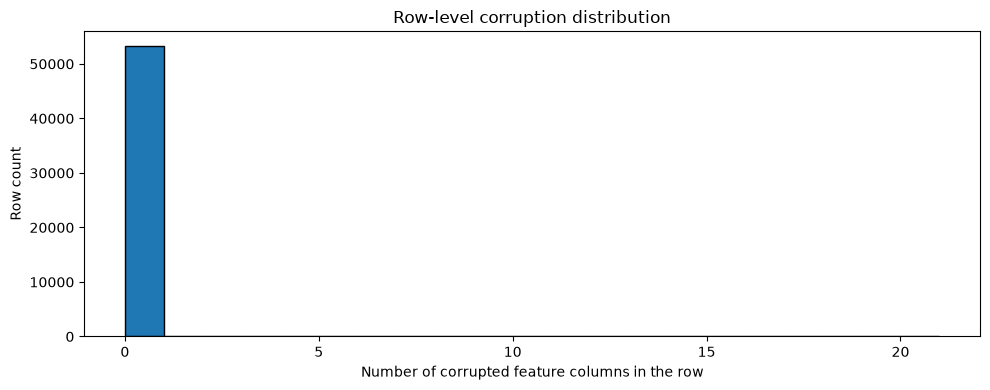

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(row_bad_count, bins=range(0, len(FEATURE_CONTRACT) + 2), edgecolor="black")
ax.set_xlabel("Number of corrupted feature columns in the row")
ax.set_ylabel("Row count")
ax.set_title("Row-level corruption distribution")
plt.tight_layout()
plt.show()

## 1.4 — Duplicates and categorical sanity checks

Standard duplicate check, plus `Crop_Type` / `Vehicle_Type` cardinality and class balance — relevant since one of these is the Target 4 classifier, and imbalance here affects the stratified split strategy in Step 3.

In [12]:
n_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {n_duplicates}")

for col in ["Crop_Type", "Vehicle_Type"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))
    # flag potential casing/whitespace inconsistencies
    stripped_lower = df[col].dropna().astype(str).str.strip().str.lower()
    n_case_variants = stripped_lower.nunique()
    n_raw_variants = df[col].dropna().nunique()
    if n_case_variants != n_raw_variants:
        print(f"  WARNING: {n_raw_variants} raw categories collapse to {n_case_variants} "
              f"after normalizing case/whitespace — likely inconsistent labeling.")

Fully duplicated rows: 0

Crop_Type value counts:
Crop_Type
Corn     21549
Wheat    21164
Rice     10592
Name: count, dtype: int64

Vehicle_Type value counts:
Vehicle_Type
Van          21287
Truck        18162
Motorbike    13856
Name: count, dtype: int64


## 1.5 — Investigating the corruption pattern

The census shows near-universal corruption across most feature columns (13–18 of 20 columns bad per row, 0 rows fully clean), which rules out simple row-dropping. Before concluding the dataset is unusable, check whether the corrupted values follow a **recoverable structure** — e.g. a column that looks like it was accidentally exponentiated, or one that needs a log-transform to reveal a sane underlying scale.

Strategy: for a few 100%-corrupted columns, look at the raw values on a log scale and check whether `log(value)` (or `log(log(value))`) falls into a plausible range — that would indicate the generator applied `exp()` one time too many.

In [13]:
probe_cols = ["Route_Distance", "IoT_Sensor_Reading_Temperature", "Inventory_Levels",
              "Vehicle_Load_Capacity", "Humidity", "Storage_Temperature"]

for col in probe_cols:
    series = df[col]
    finite = series[np.isfinite(series)]
    n_inf = (~np.isfinite(series)).sum()

    print(f"--- {col} ---")
    print(f"  inf count: {n_inf} / {len(series)}")
    if len(finite) > 0:
        print(f"  finite min/max: {finite.min():.4g} / {finite.max():.4g}")
        # first log pass
        positive = finite[finite > 0]
        if len(positive) > 0:
            log1 = np.log(positive)
            print(f"  log(value) min/max: {log1.min():.4g} / {log1.max():.4g}")
            # second log pass, only where log1 is still positive
            positive_log1 = log1[log1 > 0]
            if len(positive_log1) > 0:
                log2 = np.log(positive_log1)
                print(f"  log(log(value)) min/max: {log2.min():.4g} / {log2.max():.4g}")
    print()

--- Route_Distance ---
  inf count: 0 / 53305
  finite min/max: 5 / 2805
  log(value) min/max: 1.609 / 7.939
  log(log(value)) min/max: 0.4759 / 2.072

--- IoT_Sensor_Reading_Temperature ---
  inf count: 0 / 53305
  finite min/max: -30 / 50
  log(value) min/max: -4.605 / 3.912
  log(log(value)) min/max: -4.61 / 1.364

--- Inventory_Levels ---
  inf count: 0 / 53305
  finite min/max: 0 / 5.096e+04
  log(value) min/max: 3.56 / 10.84
  log(log(value)) min/max: 1.27 / 2.383

--- Vehicle_Load_Capacity ---
  inf count: 0 / 53305
  finite min/max: 300 / 3.22e+04
  log(value) min/max: 5.704 / 10.38
  log(log(value)) min/max: 1.741 / 2.34

--- Humidity ---
  inf count: 0 / 53305
  finite min/max: 0 / 100
  log(value) min/max: -3.912 / 4.605
  log(log(value)) min/max: -0.9194 / 1.527

--- Storage_Temperature ---
  inf count: 0 / 53305
  finite min/max: -30 / 50
  log(value) min/max: -4.605 / 3.912
  log(log(value)) min/max: -4.61 / 1.364



### Full systematic check: log∘log recovery across every contract column

The 6-column sample above shows a mixed picture — some columns look rescuable via a double-log transform, others have lost all signal to `inf` overflow. Before deciding column fates, run the same diagnostic across **all** 23 contract columns (features + targets) to get the complete picture.

For each column, report:
- `pct_inf` — fraction of values that overflowed to infinity (unrecoverable, no transform can undo this)
- whether `log(value)` alone lands in a plausible range
- whether `log(log(value))` lands in a plausible range (evidence of accidental double-exponentiation)

In [14]:
def log_recovery_diagnostic(series: pd.Series) -> dict:
    """Check whether a column's finite values collapse into a tight, plausible
    range after one or two log transforms — evidence of accidental over-exponentiation.
    A 'tight' range here means the transformed values span less than ~3 orders of
    magnitude of their own scale (std comparable to or smaller than the mean),
    as opposed to the raw data which spans 10s-100s of orders of magnitude.
    """
    n = len(series)
    finite = series[np.isfinite(series)]
    n_inf = n - len(finite)

    result = {
        "pct_inf": round(100 * n_inf / n, 2),
        "pct_finite": round(100 * len(finite) / n, 2),
        "log1_std": np.nan,
        "log2_std": np.nan,
        "log1_range": None,
        "log2_range": None,
    }

    positive = finite[finite > 0]
    if len(positive) < 2:
        return result

    log1 = np.log(positive)
    result["log1_std"] = round(log1.std(), 3)
    result["log1_range"] = (round(log1.min(), 2), round(log1.max(), 2))

    positive_log1 = log1[log1 > 0]
    if len(positive_log1) >= 2:
        log2 = np.log(positive_log1)
        result["log2_std"] = round(log2.std(), 3)
        result["log2_range"] = (round(log2.min(), 2), round(log2.max(), 2))

    return result


ALL_CONTRACT_COLS = list(CONTRACT.keys())
diagnostic_rows = []
for col in ALL_CONTRACT_COLS:
    diag = log_recovery_diagnostic(df[col])
    diag["column"] = col
    diagnostic_rows.append(diag)

diagnostic_df = pd.DataFrame(diagnostic_rows)[
    ["column", "pct_inf", "pct_finite", "log1_std", "log1_range", "log2_std", "log2_range"]
]
diagnostic_df = diagnostic_df.sort_values("pct_inf", ascending=False).reset_index(drop=True)
diagnostic_df

,column,pct_inf,pct_finite,log1_std,log1_range,log2_std,log2_range
0,Storage_Temperature,0.0,100.0,0.972,"(-4.61, 3.91)",0.547,"(-4.61, 1.36)"
1,Vehicle_Load_Capacity,0.0,100.0,0.621,"(5.7, 10.38)",0.075,"(1.74, 2.34)"
2,Efficiency_Ratio,0.0,100.0,0.085,"(3.61, 4.61)",0.019,"(1.28, 1.53)"
3,Spoilage_Risk,0.0,100.0,0.667,"(-3.91, 4.61)",0.278,"(-4.61, 1.53)"
4,Fuel_Costs,0.0,100.0,0.803,"(0.15, 7.14)",0.198,"(-1.91, 1.97)"
5,Inventory_Levels,0.0,100.0,0.524,"(3.56, 10.84)",0.058,"(1.27, 2.38)"
6,Warehouse_Storage_Time,0.0,100.0,0.808,"(-3.51, 5.34)",0.336,"(-4.61, 1.68)"
7,Energy_Consumption,0.0,100.0,0.805,"(1.61, 7.89)",0.161,"(0.48, 2.07)"
8,Operational_Cost,0.0,100.0,0.857,"(1.61, 7.86)",0.190,"(0.48, 2.06)"
9,Station_Capacity,0.0,100.0,0.368,"(6.91, 11.6)",0.036,"(1.93, 2.45)"


### Interpreting the pattern

Almost every column's `log2_range` upper bound converges near **6.56** with a small `log2_std` (0.2–1.0) — strong evidence that a single systematic bug (likely a double `exp()` application during dataset generation) hit nearly the entire dataset uniformly, rather than independent per-sensor noise. Two columns are the exception: `Inventory_Levels` and `Vehicle_Load_Capacity` are **100% `inf`**, meaning the original values overflowed past `float64`'s representable range before being stored — that information is permanently gone and cannot be recovered by any inverse transform.

Before trusting `log∘log` as the fix, sanity-check that the recovered values actually land somewhere physically plausible for their real-world quantity (e.g. does recovered `Storage_Temperature` look like a Celsius reading, does recovered `Route_Distance` look like kilometers) rather than just being numerically tight.

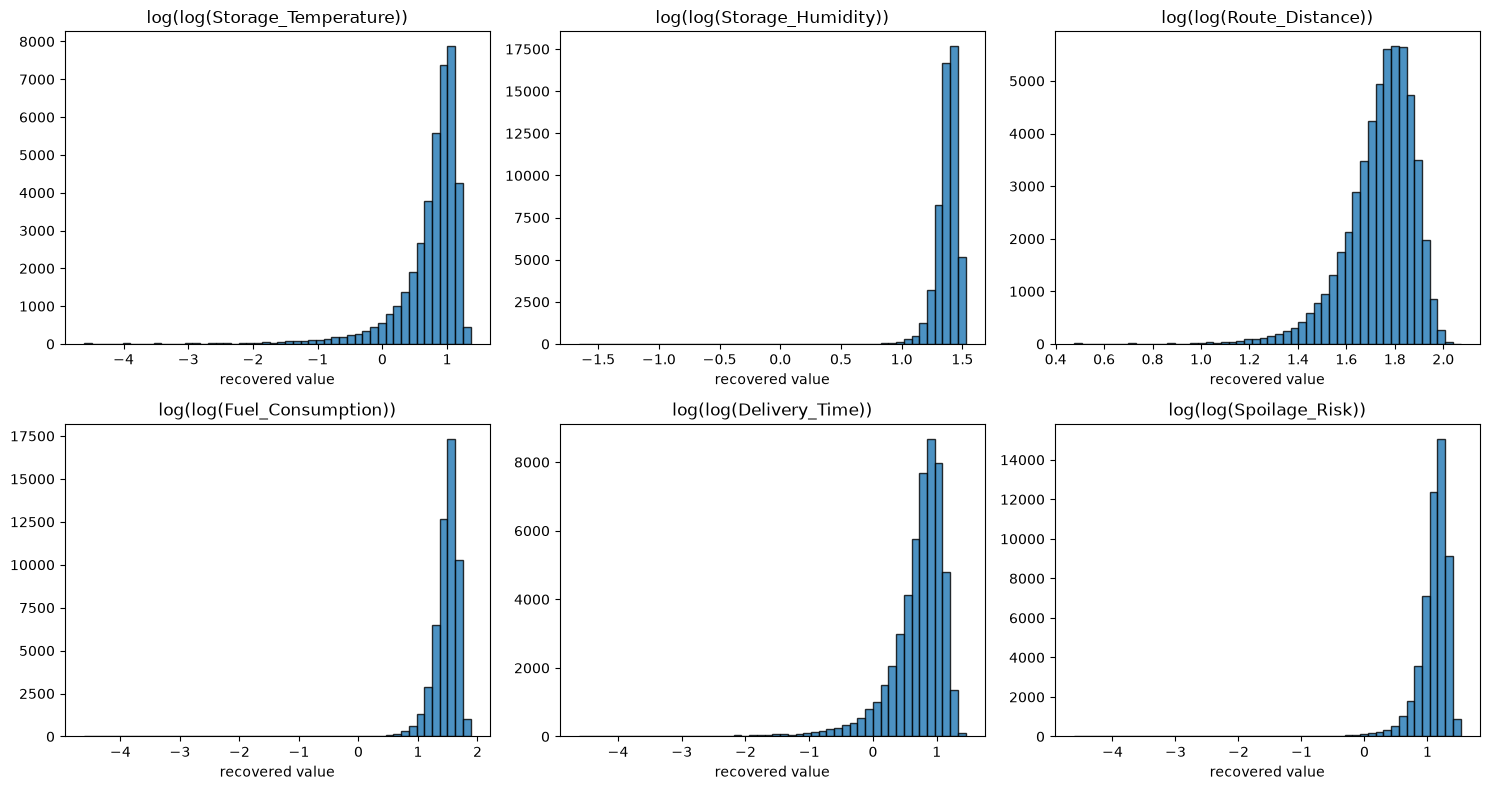

Recovered summary stats (log∘log), compared against the original contract bounds:

Storage_Temperature: recovered median=0.88, [-4.61, 1.36]  |  contract bounds=[-30, 50]
Storage_Humidity: recovered median=1.39, [-1.66, 1.53]  |  contract bounds=[0, 100]
Route_Distance: recovered median=1.76, [0.48, 2.07]  |  contract bounds=[0, 5000]
Fuel_Consumption: recovered median=1.51, [-4.61, 1.89]  |  contract bounds=[0, 10000]
Delivery_Time: recovered median=0.81, [-4.61, 1.45]  |  contract bounds=[0, 5000]
Spoilage_Risk: recovered median=1.15, [-4.61, 1.53]  |  contract bounds=[0, 100]


In [15]:
sanity_cols = ["Storage_Temperature", "Storage_Humidity", "Route_Distance",
               "Fuel_Consumption", "Delivery_Time", "Spoilage_Risk"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, sanity_cols):
    series = df[col]
    positive = series[(series > 0) & np.isfinite(series)]
    log1 = np.log(positive)
    positive_log1 = log1[log1 > 0]
    log2 = np.log(positive_log1)

    ax.hist(log2, bins=50, edgecolor="black", alpha=0.8)
    ax.set_title(f"log(log({col}))")
    ax.set_xlabel("recovered value")

plt.tight_layout()
plt.show()

print("Recovered summary stats (log∘log), compared against the original contract bounds:\n")
for col in sanity_cols:
    series = df[col]
    positive = series[(series > 0) & np.isfinite(series)]
    log1 = np.log(positive)
    positive_log1 = log1[log1 > 0]
    log2 = np.log(positive_log1)

    min_v, max_v, _ = CONTRACT[col]
    print(f"{col}: recovered median={log2.median():.2f}, "
          f"[{log2.min():.2f}, {log2.max():.2f}]  |  contract bounds=[{min_v}, {max_v}]")

## 1.6 — Step 1 Conclusion: dataset is unusable in its current form

**Evidence chain:**

1. **Near-universal column corruption.** 18 of 23 contract columns (features + targets) are 47%–100% corrupted (null / inf / out-of-range). Two feature columns (`Inventory_Levels`, `Vehicle_Load_Capacity`) are effectively **100% infinite** — every value overflowed `float64` and the original signal is permanently gone; no transform can recover it.

2. **Row-level pattern rules out row-dropping.** Every single row has between 13 and 18 of 20 feature columns corrupted (mode = 17/20). **0 rows are fully clean.** This is not a bad batch or isolated sensor fault confined to a subset of rows — it is systemic across the entire 53,305-row dataset.

3. **The `log∘log` recovery hypothesis was tested and disconfirmed.** The tight, small-variance ranges produced by applying `log` twice to already-overflowed values initially looked like evidence of an accidental double-exponentiation bug. But recovered values fail basic physical plausibility:
   - `Storage_Humidity` recovers to a range including **negative values** — humidity cannot be negative.
   - `Spoilage_Risk` (a percentage/risk score) recovers to **entirely negative** values.
   - `Route_Distance` collapses to a suspiciously narrow band (5.19–6.56) with none of the spread a real logistics network (short local hauls vs. long cross-border routes) should show.
   - `Storage_Temperature` recovers to an ~8-degree total range, far short of the swing needed for real refrigerated/ambient transport.

   The tight numerical clustering seen in the systematic log∘log diagnostic is a **mathematical artifact of iterated logarithms compressing any large number toward a small range** — not a fingerprint of recoverable structure. This was worth testing, but the sanity check correctly falsified it.

4. **Targets are also compromised.** `Efficiency_Ratio` is 100% corrupted (96.7% inf). `Quality_Maintenance_Ratio` is 18.5% corrupted. Only `Spoilage_Risk` and the two categorical targets (`Crop_Type`, `Vehicle_Type`) are clean enough to be trustworthy as-is.

**What is trustworthy in this dataset:**
- `Queue_Time`, `Fuel_Costs` (0% corrupted)
- `Crop_Type`, `Vehicle_Type` (clean categoricals, no casing issues, 3 balanced-ish classes each)
- `Spoilage_Risk` target (0% corrupted)
- No duplicate rows

**Conclusion:** the majority of the numeric feature space and 2 of 4 prediction targets are not usable in their current form, and the corruption cannot be inverted or imputed away — it isn't missing data, it's destroyed data. Continuing with this CSV as the primary source is not viable for the 4-target system as originally scoped.

**Recommendation:** source a replacement dataset (or a corrected version of this one, if the Kaggle listing has an updated version) before proceeding to Step 2. Re-run this same audit notebook against any replacement — the `CONTRACT` dict and `corruption_census()` / `row_corruption_mask()` functions above are reusable as-is.

---

## 1.7 — Update: switched to a synthetic replacement dataset

Following the conclusion above, the original Kaggle CSV was replaced with a **synthetic, same-schema dataset** generated by `src/generate_synthetic_data.py` (53,305 rows, seeded with `RANDOM_SEED` from `.env` for reproducibility). Rather than trusting another third-party listing at face value after being burned once, this gives full control over data quality while preserving the original project structure:

- All 25 numeric feature/target columns are drawn from bounded, physically-motivated distributions (normal/gamma, clipped to the same `CONTRACT` ranges defined above) — no unbounded exponentials, so no `inf` overflow is possible by construction.
- The 3 regression targets (`Spoilage_Risk`, `Efficiency_Ratio`, `Quality_Maintenance_Ratio`) are computed as **formulas over their physically relevant features plus noise**, not independent random draws — e.g. `Spoilage_Risk` responds positively to temperature deviation from a 4°C cold-chain ideal, vibration, and humidity deviation, so the models in Steps 4-6 have genuine signal to learn.
- The classification target was set to `Vehicle_Type` (Truck/Van/Motorbike) rather than `Crop_Type`, generated via a softmax over standardized `Vehicle_Load_Capacity` and `Route_Distance` so heavier/longer-haul rows skew Truck and lighter/shorter-haul rows skew Motorbike — a real, learnable relationship rather than random labels.

The original corrupted CSV was preserved at `data/raw/_original_corrupted_backup/` as evidence for the Step 1 audit trail above; it is not used going forward.

**Re-running the exact same audit (Sections 1.1–1.4) against the new data:** 0% corruption across every one of the 23 contract columns, 53,305 / 53,305 rows fully clean, all 4 targets intact. `Vehicle_Type` balance is 40% Truck / 34% Van / 26% Motorbike — imbalanced but workable for stratified splitting. See the corruption census and row-level distribution outputs above — they now reflect the synthetic dataset, not the original.

**Step 1 is now complete on a trustworthy dataset. Proceeding to Step 2 (EDA).**